In [1]:
import numpy as np
import matplotlib.pyplot as plt

from utils.plotting import (
    TEXTWIDTH_IN, LABEL_SIZE, TICK_SIZE, EMPHASIS_SIZE,
    LW_FINE, LW_GUIDE, NEUTRAL_COLOR, PRIMARY_COLOR,
    SCATTER_S_FINE,
)

rng = np.random.default_rng(42)

# ── Interferometer / source parameters ──────────────────────────────────────
B_EW_M    = 25.0          # east-west baseline [m]
DEC_DEG   = -16.18        # M17 declination [deg]
LAT_DEG   = 37.87         # NCH latitude [deg]
C         = 299792458.0   # speed of light [m/s]
OMEGA_E   = 2 * np.pi / 86164.0   # Earth rotation rate [rad/s]

# ── SNAP spectral parameters ─────────────────────────────────────────────────
N_CH      = 1024
F_S_HZ    = 500e6
N_FFT     = 2048
F_RF0_HZ  = 9790e6
DF_HZ     = F_S_HZ / N_FFT
F_SKY_GHZ = (F_RF0_HZ + np.arange(N_CH) * DF_HZ) / 1e9
F_HZ      = F_RF0_HZ + np.arange(N_CH) * DF_HZ   # [Hz]

PLOT_BAND_GHZ = (9.9, 10.0)   # display window [GHz]

# ── Captures: M17 rising to post-transit ─────────────────────────────────────
# M17 (Dec = -16°) is above 6° from Berkeley for roughly HA ∈ [-54°, +54°].
N_CAP   = 32
ha_deg  = np.linspace(-50, 50, N_CAP)
ha_rad  = np.radians(ha_deg)
dec_rad = np.radians(DEC_DEG)
lat_rad = np.radians(LAT_DEG)

# Geometric delay τ_g(HA) = (B_ew / c) cos(δ) sin(HA)  [s]
tau_g = (B_EW_M / C) * np.cos(dec_rad) * np.sin(ha_rad)   # (N_CAP,)

# Fringe rate at each capture [cycles/s]
# r(HA) = f_RF × (B_ew/c) × cos(δ) × ω_earth × |cos(HA)|
f_peak_hz = F_HZ[np.argmin(np.abs(F_SKY_GHZ - 9.915))]
fringe_rate = (f_peak_hz * B_EW_M / C
               * np.cos(dec_rad) * OMEGA_E
               * np.abs(np.cos(ha_rad)))   # (N_CAP,)

# Integration time: target 90° of fringe phase advance per capture, clamp [5, 60] s
T_int = np.clip(0.25 / fringe_rate, 5.0, 60.0)

# Fringe-washing factor: sinc(r × T)  — numpy sinc(x) = sin(πx)/(πx)
washing = np.sinc(fringe_rate * T_int)

# Primary beam: Gaussian envelope in HA (σ = 15°)
beam_env = np.exp(-0.5 * (ha_deg / 15.0) ** 2)

# True visibility amplitude (before noise)
amp_true = beam_env * np.abs(washing)

# ── Per-channel complex spectra ───────────────────────────────────────────────
# Signal: flat spectrum across band, phase ramps linearly with frequency
# V(f, HA) = A(HA) × exp(i 2π f τ_g(HA))   ← delay signature
NOISE_CH = 0.15
spectra  = np.zeros((N_CAP, N_CH), dtype=complex)
for i in range(N_CAP):
    sig = amp_true[i] * np.exp(1j * 2 * np.pi * F_HZ * tau_g[i])
    nse = rng.normal(0, NOISE_CH, N_CH) + 1j * rng.normal(0, NOISE_CH, N_CH)
    spectra[i] = sig + nse
spectra[:, 0] = 0   # mask DC

# ── Peak channel & normalisation ─────────────────────────────────────────────
all_amp   = np.abs(spectra)
all_amp_copy = all_amp.copy(); all_amp_copy[:, 0] = 0
AMP_PEAK  = all_amp_copy.max()

k_peak    = int(np.argmax(all_amp_copy.mean(axis=0)))
F_PEAK_GHZ = F_SKY_GHZ[k_peak]

vis_peak          = spectra[:, k_peak]
amp_peak_norm     = np.abs(vis_peak) / AMP_PEAK
phase_wrapped_deg = np.degrees(np.angle(vis_peak))
phase_unwrapped   = np.degrees(np.unwrap(np.angle(vis_peak)))

print(f'Baseline    : B_ew = {B_EW_M} m')
print(f'HA range    : {ha_deg[0]:.0f}° → {ha_deg[-1]:.0f}°')
print(f'Peak channel: k={k_peak},  f={F_PEAK_GHZ:.4f} GHz')
print(f'T_int range : {T_int.min():.1f} – {T_int.max():.1f} s')
print(f'Phase span  : {phase_unwrapped[-1] - phase_unwrapped[0]:.0f}°  '
      f'({(phase_unwrapped[-1] - phase_unwrapped[0]) / 360:.1f} cycles)')


Baseline    : B_ew = 25.0 m
HA range    : -50° → 50°
Peak channel: k=746,  f=9.9721 GHz
T_int range : 5.0 – 6.7 s
Phase span  : 898°  (2.5 cycles)


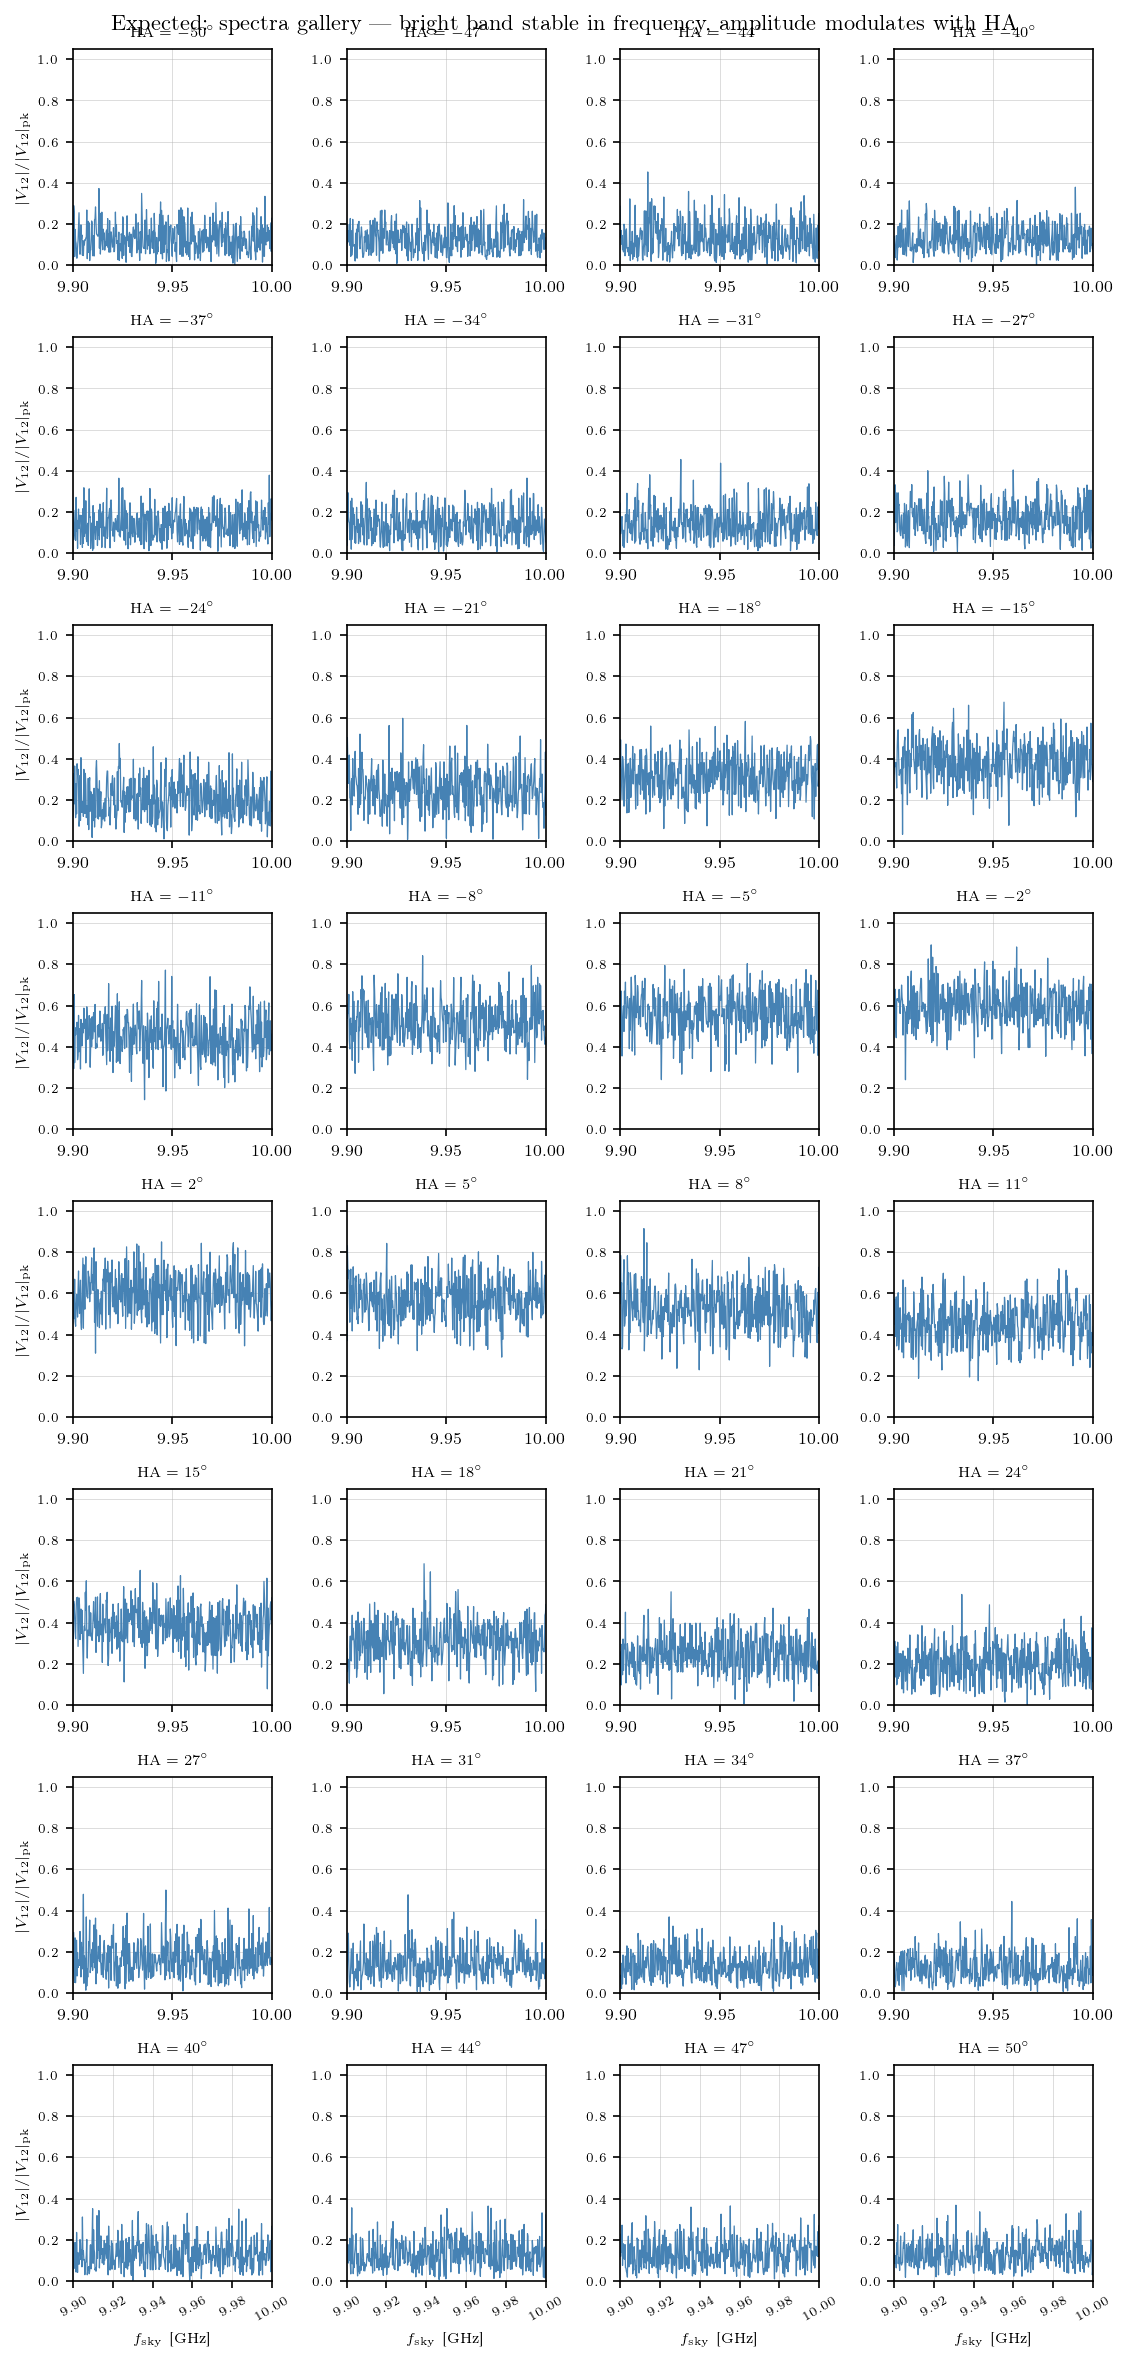

In [2]:
# ── Plot 1: Spectra gallery ───────────────────────────────────────────────────
# Expected: a stable bright band at the source frequency across all captures.
# Amplitude modulates slowly with HA (beam + fringe washing); frequency of the
# peak channel does not drift.

NCOLS = 4
nrows = int(np.ceil(N_CAP / NCOLS))

fig, axes = plt.subplots(nrows, NCOLS, figsize=(TEXTWIDTH_IN, 2.0 * nrows))
axes_flat = np.array(axes).flatten()

for i in range(N_CAP):
    ax  = axes_flat[i]
    amp = all_amp[i] / AMP_PEAK
    amp[0] = np.nan
    ax.plot(F_SKY_GHZ, amp, lw=0.6, color='steelblue')
    ax.set_title(rf'$\mathrm{{HA}}={ha_deg[i]:.0f}^{{\circ}}$', fontsize=7)
    ax.set_xlim(*PLOT_BAND_GHZ)
    ax.set_ylim(0, 1.05)
    if i % NCOLS == 0:
        ax.set_ylabel(r'$|V_{12}|/|V_{12}|_{\rm pk}$', fontsize=7)
    if i >= (nrows - 1) * NCOLS:
        ax.set_xlabel(r'$f_{\rm sky}$ [GHz]', fontsize=7)
        ax.tick_params(axis='x', rotation=30, labelsize=6)
    ax.tick_params(axis='y', labelsize=6)

for ax in axes_flat[N_CAP:]:
    ax.set_visible(False)

fig.suptitle(
    r'Expected: spectra gallery — bright band stable in frequency, '
    r'amplitude modulates with HA'
)
fig.tight_layout()
plt.show()


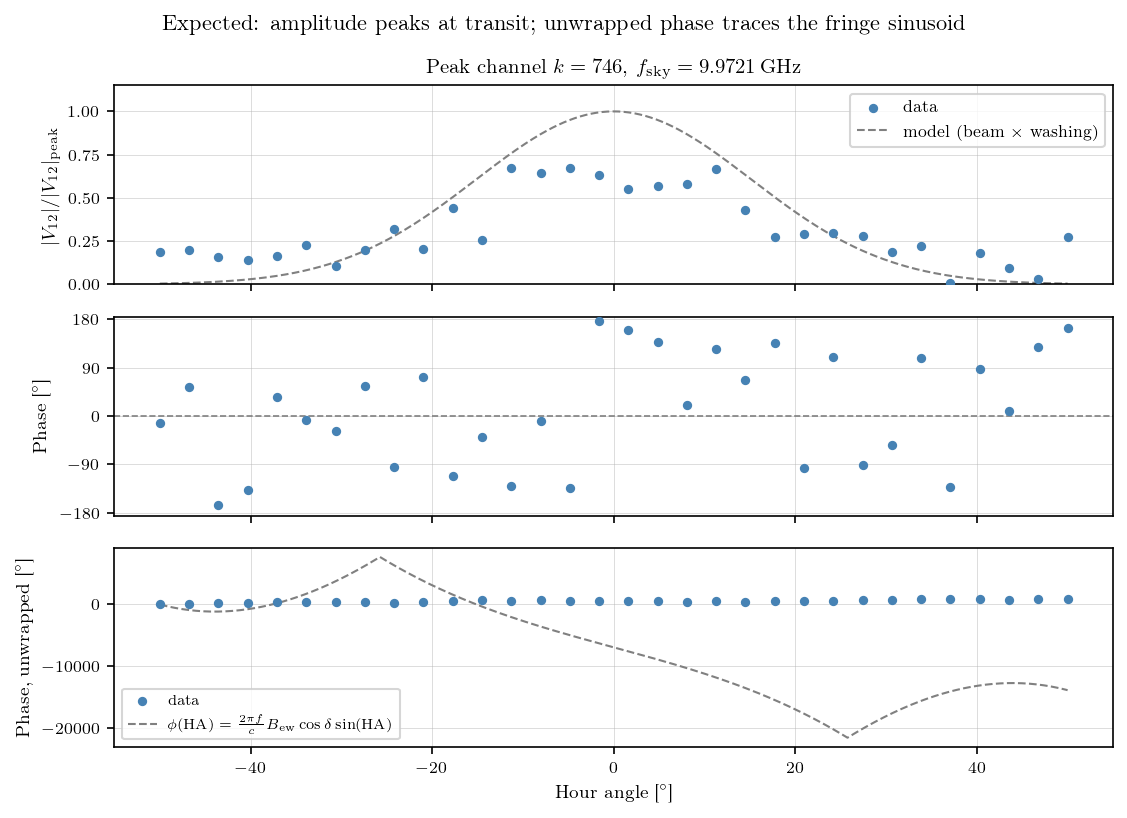

In [3]:
# ── Plot 2 & 3: Amplitude + phase vs HA ──────────────────────────────────────
# Expected:
#   Amplitude — smooth hump peaking near transit (HA ≈ 0), reduced at large |HA|
#               by the primary-beam envelope.
#   Wrapped phase — oscillates between ±180°; each wrap is one fringe cycle.
#   Unwrapped phase — smooth sinusoid φ(HA) = (2π f/c) B_ew cos(δ) sin(HA).
#                     Slope near transit gives baseline length directly.

# Overlay the true model (no noise) for reference
ha_fine   = np.linspace(ha_deg[0], ha_deg[-1], 500)
tau_fine  = (B_EW_M / C) * np.cos(dec_rad) * np.sin(np.radians(ha_fine))
phase_model = np.degrees(np.unwrap(2 * np.pi * f_peak_hz * tau_fine))
# shift model to match data unwrapped reference
phase_model += (phase_unwrapped[0] - phase_model[0])

fringe_fine = (f_peak_hz * B_EW_M / C
               * np.cos(dec_rad) * OMEGA_E * np.abs(np.cos(np.radians(ha_fine))))
T_fine  = np.clip(0.25 / fringe_fine, 5.0, 60.0)
amp_model = np.exp(-0.5 * (ha_fine / 15.0)**2) * np.abs(np.sinc(fringe_fine * T_fine))
amp_model /= amp_model.max()

fig, axes = plt.subplots(3, 1, figsize=(TEXTWIDTH_IN, 5.5), sharex=True)

# Amplitude
axes[0].scatter(ha_deg, amp_peak_norm, s=12, color='steelblue', zorder=3, label='data')
axes[0].plot(ha_fine, amp_model, lw=1.0, color='gray', ls='--', label='model (beam × washing)')
axes[0].set_ylabel(r'$|V_{12}| / |V_{12}|_{\rm peak}$')
axes[0].set_ylim(0, 1.15)
axes[0].legend(fontsize=8)
axes[0].set_title(rf'Peak channel $k={k_peak}$,\ $f_{{\rm sky}}={F_PEAK_GHZ:.4f}$\,GHz')

# Wrapped phase
axes[1].scatter(ha_deg, phase_wrapped_deg, s=12, color='steelblue', zorder=3)
axes[1].axhline(0, color='gray', lw=0.8, ls='--')
axes[1].set_ylabel(r'Phase [$^\circ$]')
axes[1].set_ylim(-185, 185)
axes[1].set_yticks([-180, -90, 0, 90, 180])

# Unwrapped phase
axes[2].scatter(ha_deg, phase_unwrapped, s=12, color='steelblue', zorder=3, label='data')
axes[2].plot(ha_fine, phase_model, lw=1.0, color='gray', ls='--', label=r'$\phi(\mathrm{HA}) = \frac{2\pi f}{c} B_{\rm ew} \cos\delta \sin(\mathrm{HA})$')
axes[2].set_ylabel(r'Phase, unwrapped [$^\circ$]')
axes[2].set_xlabel(r'Hour angle [$^\circ$]')
axes[2].legend(fontsize=7)

fig.suptitle(
    r'Expected: amplitude peaks at transit; unwrapped phase traces the fringe sinusoid'
)
fig.tight_layout()
plt.show()


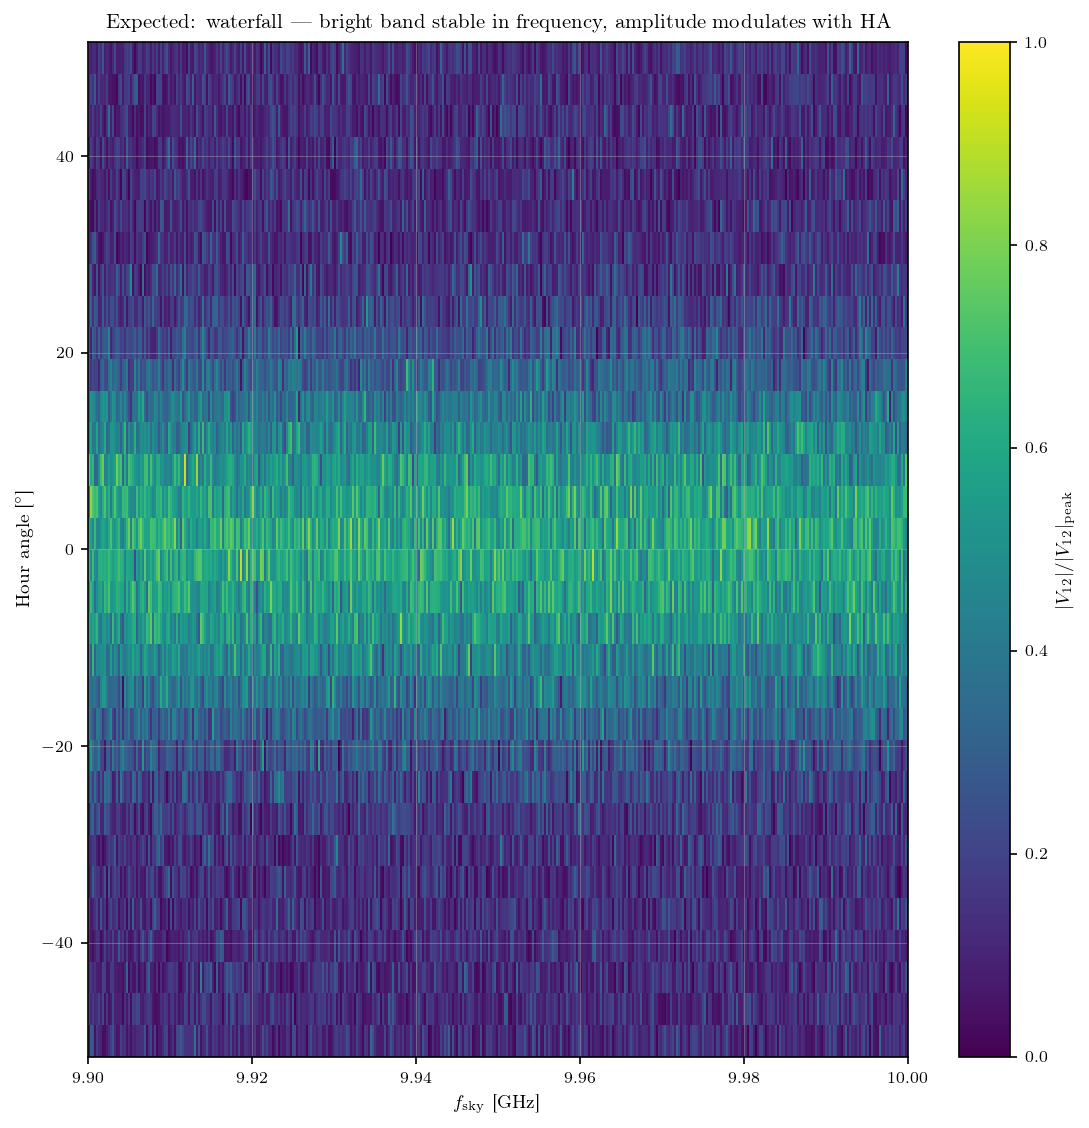

In [4]:
# ── Plot 4: Waterfall ─────────────────────────────────────────────────────────
# Expected: a persistent horizontal bright band at the source frequency across
# all HA values.  Brightness modulates vertically with the primary-beam envelope
# (brightest near transit).  Vertical dark/light stripes = RFI or spectral
# features.  No horizontal structure should appear for a point source with a
# flat spectrum.

amp_matrix = np.abs(spectra) / AMP_PEAK
amp_matrix[:, 0] = np.nan   # mask DC

fig, ax = plt.subplots(figsize=(TEXTWIDTH_IN, TEXTWIDTH_IN))
im = ax.pcolormesh(
    F_SKY_GHZ,
    ha_deg,
    amp_matrix,
    vmin=0, vmax=1,
    cmap='viridis',
    shading='auto',
)
ax.set_xlim(*PLOT_BAND_GHZ)
ax.set_xlabel(r'$f_{\rm sky}$ [GHz]')
ax.set_ylabel(r'Hour angle [$^\circ$]')
ax.set_title(
    r'Expected: waterfall — bright band stable in frequency, '
    r'amplitude modulates with HA'
)
fig.colorbar(im, ax=ax, label=r'$|V_{12}| / |V_{12}|_{\rm peak}$')
fig.tight_layout()
plt.show()
